# Data profiling

## tl;dr
The source inventory, column profile and fan-out audit are the trust foundation for every downstream metric.


## Context & Methods

The notebook reads the generated QA artifacts and keeps source grain visible. The payment/order-item fan-out is treated as a material risk.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd().parent
qa = root / 'reports' / 'qa'
inventory = pd.read_csv(qa / 'raw_inventory.csv')
profile = pd.read_csv(qa / 'data_profile_summary.csv')
fanout = pd.read_csv(qa / 'fanout_audit.csv')
inventory, profile.head()


(                           table_name  row_count  column_count  \
 0             olist_customers_dataset      99441             5   
 1           olist_geolocation_dataset    1000163             5   
 2           olist_order_items_dataset     112650             7   
 3        olist_order_payments_dataset     103886             5   
 4         olist_order_reviews_dataset      99224             7   
 5                olist_orders_dataset      99441             8   
 6              olist_products_dataset      32951             9   
 7               olist_sellers_dataset       3095             4   
 8   product_category_name_translation         71             2   
 9                  closed_deals_olist        842            14   
 10    marketing_qualified_leads_olist       8000             4   
 
                                         candidate_key  duplicate_key_count  \
 0                                         customer_id                    0   
 1   zip_code_prefix + geolocation_l

## Results

### Inventory and fan-out


,table_name,row_count,column_count,candidate_key,duplicate_key_count,date_min,date_max,file_size_mb
0,olist_customers_dataset,99441,5,customer_id,0,NaN,NaN,NaN
1,olist_geolocation_dataset,1000163,5,zip_code_prefix + geolocation_lat + geolocatio...,261831,NaN,NaN,NaN
2,olist_order_items_dataset,112650,7,order_id + order_item_id,0,2016-09-19 00:15:34,2020-04-09 22:35:08,NaN
3,olist_order_payments_dataset,103886,5,order_id + payment_sequential,0,NaN,NaN,NaN
4,olist_order_reviews_dataset,99224,7,review_id,814,2016-10-02 00:00:00,2018-10-29 12:27:35,NaN
5,olist_orders_dataset,99441,8,order_id,0,2016-09-04 21:15:19,2018-11-12 00:00:00,NaN
6,olist_products_dataset,32951,9,product_id,0,NaN,NaN,NaN
7,olist_sellers_dataset,3095,4,seller_id,0,NaN,NaN,NaN
8,product_category_name_translation,71,2,product_category_name,0,NaN,NaN,NaN
9,closed_deals_olist,842,14,mql_id,0,2017-12-05 02:00:00,2018-11-14 18:04:19,NaN


,raw_order_count,joined_row_count,grain_safe_item_gmv,naive_joined_gmv,fanout_difference,fanout_multiple
0,99441,117601,13591643.7,14209115.34,617471.64,1.04543


Grain-safe GMV: 13,591,643.70; naive joined GMV: 14,209,115.34; multiple: 1.045


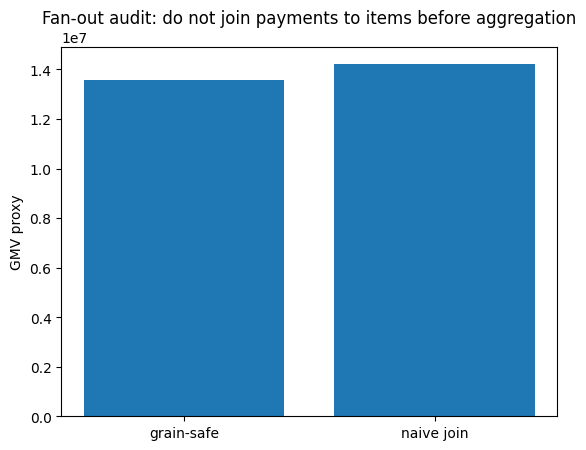

In [2]:
display(inventory)
display(fanout)
row = fanout.iloc[0]
print(f"Grain-safe GMV: {row['grain_safe_item_gmv']:,.2f}; naive joined GMV: {row['naive_joined_gmv']:,.2f}; multiple: {row['fanout_multiple']:.3f}")
plt.bar(['grain-safe','naive join'], [row['grain_safe_item_gmv'], row['naive_joined_gmv']])
plt.ylabel('GMV proxy')
plt.title('Fan-out audit: do not join payments to items before aggregation')
plt.show()


## Takeaways

The safe metric path is order-item price aggregated before payment joins. The audit is retained as a regression test.
